# **1. Generación de Ingredientes con GPT**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion5/1-text-generation.ipynb)

El objetivo de este proyecto es desarrollar un modelo de generación de texto basado en arquitecturas tipo GPT (Generative Pre-trained Transformer), con el fin de producir **listas de ingredientes coherentes y plausibles** a partir de una **categoría culinaria**.

En este enfoque se plantea una tarea más específica y controlada: **aprender la relación entre el tipo de receta y los ingredientes que normalmente la componen**.

Lo anterior responde a dos razones principales:

**a**. **Simplificación de la tarea generativa**  
   En vez de usar el dataset para generar recetas completas, lo cual implica modelar secuencias largas, con varios componentes narrativos y procedimentales (nombre, ingredientes, pasos, e incluso metadatos adicionales); se generan únicamente ingredientes, lo que permite reducir la complejidad del problema y concentrar el aprendizaje en un patrón semántico más acotado.

**b.** **Mayor viabilidad computacional**  
   Al trabajar con secuencias más cortas, el costo de tokenización y entrenamiento disminuye considerablemente. Esto abre la posibilidad de entrenar el modelo con una porción mucho mayor del dataset, e incluso potencialmente con la totalidad de los ejemplos disponibles, manteniendo la viabilidad en Google Colab con GPU T4.

En este sentido, el proyecto busca evaluar si un modelo GPT en español puede aprender asociaciones útiles entre categorías culinarias e ingredientes frecuentes, por ejemplo:

- postres → azúcar, harina, leche, canela
- sopas → agua, cebolla, ajo, zanahoria

---

## **Descripción del dataset**

Para este proyecto se utiliza el dataset **"RecetasDeLaAbuela" (SomosNLP)**.

Este dataset corresponde a un corpus estructurado de recetas de cocina en español, construido a partir de técnicas de *web scraping* sobre múltiples fuentes gastronómicas.

### **Características principales**

- Más de 20 mil recetas
- Aproximadamente 6 millones de palabras
- Más de 40 millones de caracteres
- Dataset tabular con 14 atributos por receta

### **Estructura del dataset**

Cada receta contiene los siguientes atributos:

- **Id**: Identificador único
- **Nombre**: Nombre de la receta
- **URL**: Fuente de origen
- **Ingredientes**: Lista de ingredientes
- **Pasos**: Instrucciones de preparación
- **Pais**: Origen geográfico
- **Duracion**: Tiempo estimado de preparación
- **Categoria**: Tipo de receta (postres, carnes, vegetarianos, etc.)
- **Contexto**: Entorno de consumo
- **Valoracion y Votos**
- **Comensales**
- **Tiempo**
- **Dificultad**
- **Valor nutricional**

---

## **Justificación**

Aunque el dataset contiene suficiente información para generar recetas completas, en esta versión del proyecto se decide trabajar únicamente con los campos:

- **Categoria**
- **Ingredientes**

La razón de esta decisión es que estos dos atributos contienen el núcleo de la relación semántica que se quiere modelar: **qué ingredientes suelen asociarse a cada tipo de receta**.

En cambio, otros campos como `Pasos`, `Nombre` o `Pais`, aunque útiles en un escenario de generación más amplio, incrementan la longitud de las secuencias y la complejidad del aprendizaje, lo que dificulta el entrenamiento completo del modelo bajo restricciones computacionales.

Así, este diseño permite:

- reducir la longitud promedio de las secuencias,
- aprovechar una mayor proporción del dataset,
- mejorar la estabilidad del entrenamiento,
- y enfocar el aprendizaje en una tarea más concreta y medible.

---

## **Metodología**

El proyecto seguirá las siguientes etapas:

### **a. Exploratory Data Analysis (EDA)**
Se realizará un análisis exploratorio del dataset completo para comprender:

- la estructura general del corpus,
- la calidad de los campos disponibles,
- la presencia de valores faltantes,
- la distribución de categorías,
- y la longitud de los textos.

Aunque el modelado final solo utilizará `Categoria` e `Ingredientes`, el EDA se mantendrá sobre el dataset completo porque sigue siendo útil para contextualizar el problema y justificar la selección de variables.

### **b. Selección de variables**
A partir del análisis estructural, se seleccionarán los campos:

- `Categoria`
- `Ingredientes`

Estos serán transformados en un texto unificado que sirva de entrada para el modelo.

### **c. Construcción del texto objetivo**
Cada ejemplo será representado con una estructura simple y consistente, por ejemplo:

```text
### Categoría:
postres

### Ingredientes:
azúcar, harina, leche, mantequilla, canela

```

## **Selección del modelo base**

Para este proyecto se seleccionó el modelo **`mrm8488/spanish-gpt2`**, una variante de GPT-2 preentrenada en español.

La elección de este modelo responde a un proceso iterativo que combinó criterios teóricos y evidencia empírica.

Inicialmente, se exploró el uso de modelos alternativos como `DeepESP/gpt2-spanish`, con el objetivo de evaluar distintas opciones disponibles en el ecosistema de Hugging Face. Sin embargo, durante las pruebas iniciales se identificaron problemas de estabilidad, incluyendo advertencias en la carga de pesos y comportamientos inconsistentes durante el entrenamiento (valores extremos y `NaN` en la función de pérdida).

En consecuencia, se selecciona `mrm8488/spanish-gpt2` como modelo base para el proceso de fine-tuning, priorizando estabilidad, reproducibilidad y adecuación al problema planteado.




#### Referencias
- Dataset: [RecetasDeLaAbuela (SomosNLP)](https://huggingface.co/datasets/somosnlp/RecetasDeLaAbuela?utm_source=chatgpt.com)  
- [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)  
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)  
- [GPT2-base-bne (Modelo en español - PlanTL)](https://huggingface.co/PlanTL-GOB-ES/gpt2-base-bne)  
- [Fine-Tune a non-English GPT-2 Model with Hugging Face](https://www.philschmid.de/fine-tune-a-non-english-gpt-2-model-with-huggingface)  
- [SomosNLP - Comunidad de NLP en español](https://huggingface.co/somosnlp)  

In [ ]:
!pip -q install transformers datasets evaluate accelerate sentencepiece wordcloud

In [ ]:
import os
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

import torch
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments
)

warnings.filterwarnings("ignore")

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
# Carga del modelo base y tokenizer

model_ckpt = "mrm8488/spanish-gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForCausalLM.from_pretrained(model_ckpt).to(device)

# GPT-2 no suele incluir pad_token por defecto
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.config.pad_token_id = tokenizer.pad_token_id

print("Modelo cargado:", model_ckpt)
print("Dispositivo:", device)
print("Pad token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)
print("Tamaño del vocabulario:", tokenizer.vocab_size)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado: mrm8488/spanish-gpt2
Dispositivo: cuda
Pad token: <|endoftext|>
EOS token: <|endoftext|>
Tamaño del vocabulario: 50265


# **2. Carga e Inspección del Dataset**

Una vez seleccionado el modelo base, el siguiente paso consiste en cargar e inspeccionar el dataset **RecetasDeLaAbuela**.

Esta etapa es fundamental porque permite:

- verificar el tamaño real del corpus,
- identificar las columnas disponibles,
- revisar el formato de cada atributo,
- detectar posibles valores faltantes,
- y entender cómo debe construirse el texto final que será usado para el fine-tuning.

Dado que el objetivo del proyecto es generar recetas completas y coherentes, resulta especialmente importante inspeccionar cómo vienen representados los campos más relevantes, como el **nombre de la receta**, los **ingredientes** y los **pasos de preparación**.

In [ ]:
# Carga del dataset

from datasets import load_dataset

dataset = load_dataset("somosnlp/RecetasDeLaAbuela", "version_1")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['Id', 'Nombre', 'URL', 'Ingredientes', 'Pasos', 'Pais', 'Duracion', 'Categoria', 'Contexto', 'Valoracion y Votos', 'Comensales', 'Tiempo', 'Dificultad', 'Valor nutricional'],
        num_rows: 20236
    })
})


In [ ]:
# Inspección inicial de la estructura

print("Splits disponibles:", list(dataset.keys()))
print("\nColumnas del dataset:")
print(dataset["train"].column_names)

print("\nPrimer registro:")
print(dataset["train"][0])

Splits disponibles: ['train']

Columnas del dataset:
['Id', 'Nombre', 'URL', 'Ingredientes', 'Pasos', 'Pais', 'Duracion', 'Categoria', 'Contexto', 'Valoracion y Votos', 'Comensales', 'Tiempo', 'Dificultad', 'Valor nutricional']

Primer registro:
{'Id': 1, 'Nombre': 'Tacos Dorados de Papa', 'URL': 'https://www.mexicoenmicocina.com/tacos-dorados-de-papa/', 'Ingredientes': '½ taza de cilantro finamente picado, 1 taza de tomate picadito y sin semillas, 1 cucharada de jugo de limón, 12 to rtillas de maíz, ⅔ de taza de aceite vegetal para freír los taquitos, 2 chiles serranos en cubitos, Sal al gusto, 2 tazas de repollo en tiras finas, ½ taza de crema mexicana, Salsa roja, ½ taza de cebolla blanca en cubitos, 3 papas rojas de tamaño mediano ~510 gr. *, 24 palillos de madera para sostener los taquitos enrollados, 1 aguacate opcional, Sal y pimienta al gusto, ½ taza de Queso Cotija o Queso Fresco desmenuzado**', 'Pasos': 'Pon las papas enteras en una olla mediana y cúbrelas con agua fría. NO p

In [ ]:
# Tamaño del dataset

print("Número de registros en train:", len(dataset["train"]))

Número de registros en train: 20236


In [ ]:
# Vista tabular de algunos ejemplos

sample_df = pd.DataFrame(dataset["train"][:5])
sample_df.head()

,Id,Nombre,URL,Ingredientes,Pasos,Pais,Duracion,Categoria,Contexto,Valoracion y Votos,Comensales,Tiempo,Dificultad,Valor nutricional
0,1,Tacos Dorados de Papa,https://www.mexicoenmicocina.com/tacos-dorados...,"½ taza de cilantro finamente picado, 1 taza de...",Pon las papas enteras en una olla mediana y cú...,MEX,01:00,vegetarianos,None,None,6,None,None,"Alto en calorías, Alto en grasas, Alto en sodio"
1,2,Ensalada de Chayotes,https://www.mexicoenmicocina.com/receta-ensala...,"½ cucharadita sal, ¼ cucharadita de pimienta r...",Coloca los chayotes en una cacerola y cúbralos...,MEX,00:25,vegetarianos,None,None,4,None,None,"Bajo en calorías, Sin grasa, Alto en fibra"
2,3,Huevos a la Mexicana,https://www.mexicoenmicocina.com/huevos-a-la-m...,"½ Chile Serrano cortado en pequeños trocitos*,...",Calienta el aceite en una sartén mediana a fue...,MEX,00:15,vegetarianos,None,None,1,None,None,"Alto en calorías, Alto en grasas, Alto en sodio"
3,4,Rajas de Chile Poblano con Crema,https://www.mexicoenmicocina.com/rajas-de-chil...,"½ cucharadita Sal, 2 cucharadas de aceite vege...",Para asar los chiles:Colocas los chiles ya lim...,MEX,00:30,vegetarianos,None,None,None,None,None,"Alto en calorías, Alto en grasas, Alto en sodio"
4,5,Papas a la Mexicana,https://www.mexicoenmicocina.com/papas-a-la-me...,"⅓ taza de cebolla blanca en cubitos, Sal al gu...",Calienta el aceite vegetal en una sartén grand...,MEX,00:25,vegetarianos,None,None,None,None,None,"Alto en calorías, Alto en grasas, Alto en sodio"


# **3. Análisis estructural del dataset y estrategia de formateo**

## **Selección de variables**

A partir del análisis exploratorio del dataset, se identificaron múltiples atributos disponibles por receta, incluyendo nombre, ingredientes, pasos, país, categoría y otros metadatos.

Sin embargo, para el enfoque actual del proyecto, se decidió trabajar únicamente con los siguientes campos:

- **Categoria**
- **Ingredientes**

## **Justificación**

En lugar de generar recetas completas, se busca modelar la relación entre el tipo de receta y los ingredientes que la componen.

En particular:

- **Categoria** actúa como una variable de contexto que condiciona la generación.
- **Ingredientes** representa el contenido objetivo que el modelo debe aprender a generar.

Otros atributos como `Pasos`, `Nombre` o `Pais`, aunque relevantes en escenarios más complejos, incrementan significativamente la longitud de las secuencias y la dificultad del entrenamiento.

Dado que el objetivo es entrenar el modelo con una mayor proporción del dataset (idealmente completo), se prioriza una representación más compacta del texto.

El modelo será entrenado para aprender una función del tipo: Categoria -> Ingredientes, lo cual constituye una tarea de generación condicionada más simple, interpretable y eficiente computacionalmente.


## **3.1 Revisar nulos y calidad de columnas**

In [ ]:
# Revisión de valores faltantes


df_raw = pd.DataFrame(dataset["train"])

missing_counts = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (df_raw.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct.round(2)
})

missing_df

,missing_count,missing_pct
Tiempo,9678,47.83
Contexto,8723,43.11
Valoracion y Votos,6915,34.17
Categoria,6748,33.35
Duracion,6630,32.76
Comensales,6627,32.75
Dificultad,6454,31.89
Pais,5591,27.63
Pasos,0,0.00
Nombre,0,0.00


El análisis de valores faltantes muestra que los campos principales del contenido narrativo de las recetas (`Nombre`, `Ingredientes`, `Pasos`) no presentan valores nulos, lo cual garantiza una base sólida para el entrenamiento del modelo.

Sin embargo, variables adicionales como `Categoría` y `País` presentan niveles moderados de datos faltantes (27%–33%), mientras que otras variables superan el 40% de ausencia.

Dado este comportamiento, se decide incluir `País` y `Categoría` como variables opcionales dentro del texto, permitiendo enriquecer el contexto sin comprometer la consistencia del dataset.

## **3.2 Longitud básica de campos principales**

In [ ]:
#  Longitud de los campos principales

df_raw["len_nombre_chars"] = df_raw["Nombre"].fillna("").apply(len)
df_raw["len_ingredientes_chars"] = df_raw["Ingredientes"].fillna("").apply(len)
df_raw["len_pasos_chars"] = df_raw["Pasos"].fillna("").apply(len)

df_raw[[
    "len_nombre_chars",
    "len_ingredientes_chars",
    "len_pasos_chars"
]].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

,len_nombre_chars,len_ingredientes_chars,len_pasos_chars
count,20236.000000,20236.000000,20236.000000
mean,25.491550,250.859705,1169.780737
std,8.630606,123.129856,683.839363
min,3.000000,2.000000,40.000000
50%,25.000000,232.000000,1075.000000
75%,31.000000,313.000000,1551.000000
90%,37.000000,408.000000,2041.000000
95%,40.000000,479.000000,2393.000000
99%,49.000000,641.300000,3171.300000
max,78.000000,1261.000000,10611.000000


El análisis de longitud revela que el campo `Pasos` concentra la mayor cantidad de información textual, con una mediana superior a 1000 caracteres y una cola larga que alcanza valores extremos.

Esto implica que el modelo deberá aprender principalmente patrones de generación secuencial largos, propios de instrucciones culinarias.

Sin embargo, también introduce un desafío: el manejo de secuencias largas en modelos GPT-2, que tienen limitaciones de longitud máxima.

## **3.3 Distribución de categorías**

Categoria
Desconocido                                                      6748
[]                                                               5614
['Recetas al horno']                                             1230
['Recetas mexicanas']                                             584
['Recomendada para perder peso']                                  324
['Recetas españolas']                                             309
['Recomendada para vegetarianos']                                 297
['Recomendada para veganos']                                      235
['Recomendada para veganos', 'Recomendada para vegetarianos']     226
['Recetas para Navidad']                                          180
['Recomendada para vegetarianos', 'Recetas al horno']             166
['Recetas peruanas']                                              111
['Recetas italianas']                                             103
['Recetas colombianas']                                            84
['Recetas 

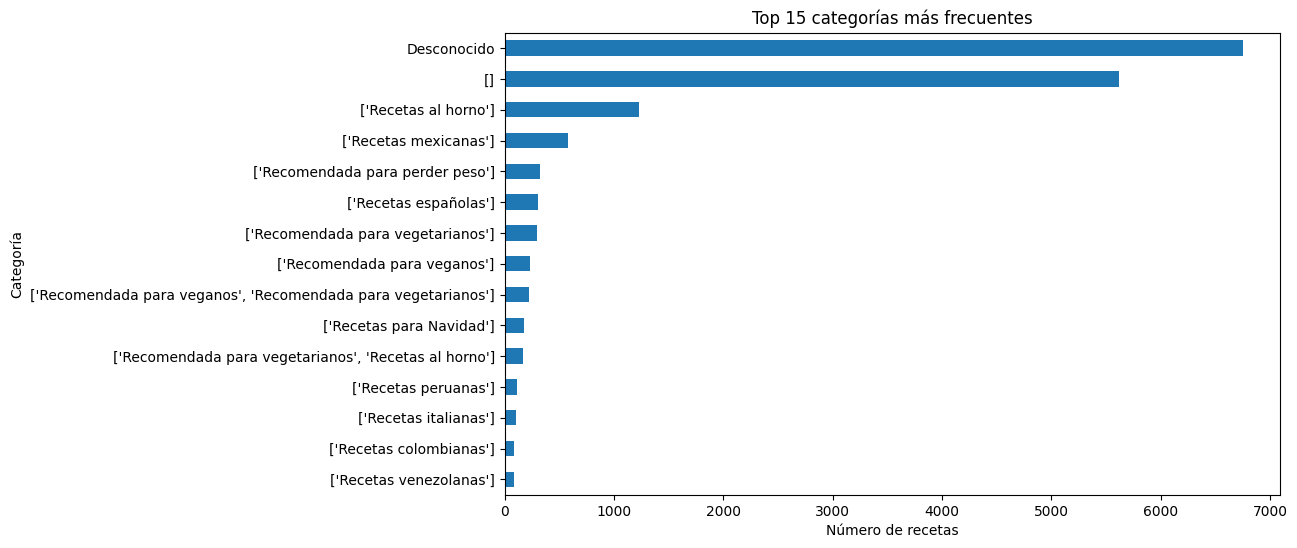

In [ ]:
# Categorías más frecuentes

top_categorias = df_raw["Categoria"].fillna("Desconocido").value_counts().head(15)
print(top_categorias)

plt.figure(figsize=(10,6))
top_categorias.sort_values().plot(kind="barh")
plt.title("Top 15 categorías más frecuentes")
plt.xlabel("Número de recetas")
plt.ylabel("Categoría")
plt.show()

Hallazgo CRÍTICO: Mucho "Desconocido"

Categorías mal formateadas ([], listas como texto). Se debe limpiar esta categoria



## **3.4 Distribución por país**

Pais
ESP            9381
Desconocido    5591
MEX            2256
PER            1277
ARG             627
CHL             250
COL             244
VEN             204
PRI              82
CUB              73
ECU              55
DOM              37
SLV              37
GTM              34
URY              20
Name: count, dtype: int64


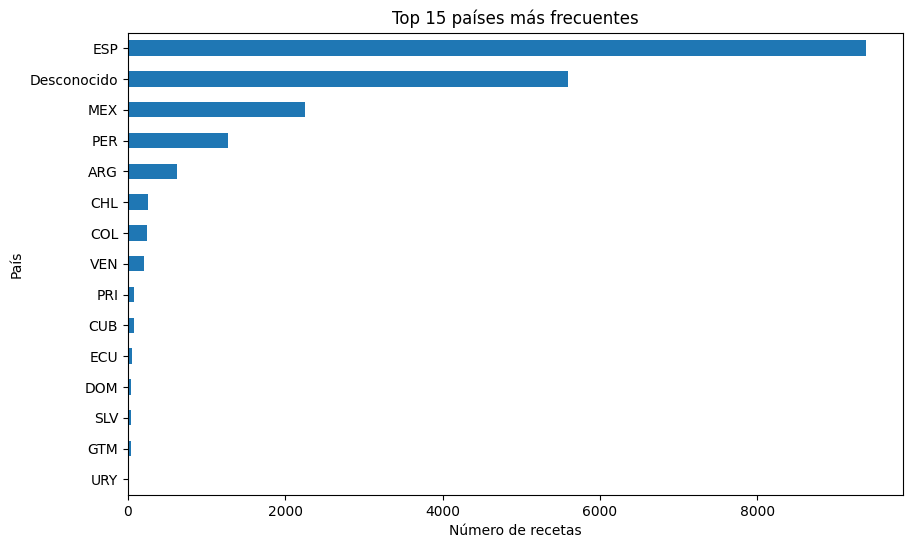

In [ ]:
# Países más frecuentes

top_paises = df_raw["Pais"].fillna("Desconocido").value_counts().head(15)
print(top_paises)

plt.figure(figsize=(10,6))
top_paises.sort_values().plot(kind="barh")
plt.title("Top 15 países más frecuentes")
plt.xlabel("Número de recetas")
plt.ylabel("País")
plt.show()

Hallazgo:

España domina fuertemente. Luego México y Perú. Hay mezcla latinoamericana.

## **3.5 Construcción del texto unificado**

Una vez seleccionadas las variables relevantes (`Categoria` e `Ingredientes`), se construye una representación textual uniforme para cada receta.

El objetivo es que el modelo aprenda patrones de asociación entre la categoría culinaria y los ingredientes típicos que la componen.

Cada ejemplo se transforma en el siguiente formato:

- Categoría: postres
- Ingredientes: azúcar, harina, leche, mantequilla, canela


Este formato permite:

- mantener consistencia en la estructura del input,
- facilitar el aprendizaje de relaciones semánticas,
- y permitir generación condicionada a partir de la categoría.


In [ ]:
# Construcción del texto final (categoría → ingredientes)


def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).replace("\xa0", " ").strip()
    x = " ".join(x.split())
    return x

def build_ingredient_text(example):
    categoria = clean_text(example["Categoria"])
    ingredientes = clean_text(example["Ingredientes"])

    text = f"""### Categoría:
{categoria}

### Ingredientes:
{ingredientes}"""

    return {"text": text}

formatted_dataset = dataset.map(build_ingredient_text)

## **3.6 Verificar el texto generado**

In [ ]:
print(formatted_dataset["train"][0]["text"])

### Categoría:
vegetarianos

### Ingredientes:
½ taza de cilantro finamente picado, 1 taza de tomate picadito y sin semillas, 1 cucharada de jugo de limón, 12 to rtillas de maíz, ⅔ de taza de aceite vegetal para freír los taquitos, 2 chiles serranos en cubitos, Sal al gusto, 2 tazas de repollo en tiras finas, ½ taza de crema mexicana, Salsa roja, ½ taza de cebolla blanca en cubitos, 3 papas rojas de tamaño mediano ~510 gr. *, 24 palillos de madera para sostener los taquitos enrollados, 1 aguacate opcional, Sal y pimienta al gusto, ½ taza de Queso Cotija o Queso Fresco desmenuzado**


# **4. EDA para modelado**

En esta etapa se profundiza en el análisis del corpus con el objetivo de tomar decisiones clave para el entrenamiento del modelo.

En particular, se busca:

- determinar la longitud adecuada de secuencia (`max_length`)
- entender la distribución de tokens
- identificar patrones léxicos relevantes
- evaluar la complejidad del lenguaje culinario

Estas decisiones son fundamentales para garantizar que el modelo pueda aprender eficientemente sin exceder las limitaciones computacionales del entorno (GPU T4).

## **4.1 Longitud en palabras**

In [ ]:
# Longitud en palabras


df_text = pd.DataFrame(formatted_dataset["train"])

df_text["word_len"] = df_text["text"].apply(lambda x: len(x.split()))

df_text["word_len"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

,word_len
count,20236.000000
mean,46.726626
std,20.322203
min,5.000000
50%,44.000000
75%,58.000000
90%,72.000000
95%,84.000000
99%,109.000000
max,213.000000


## **4.2 Histograma**

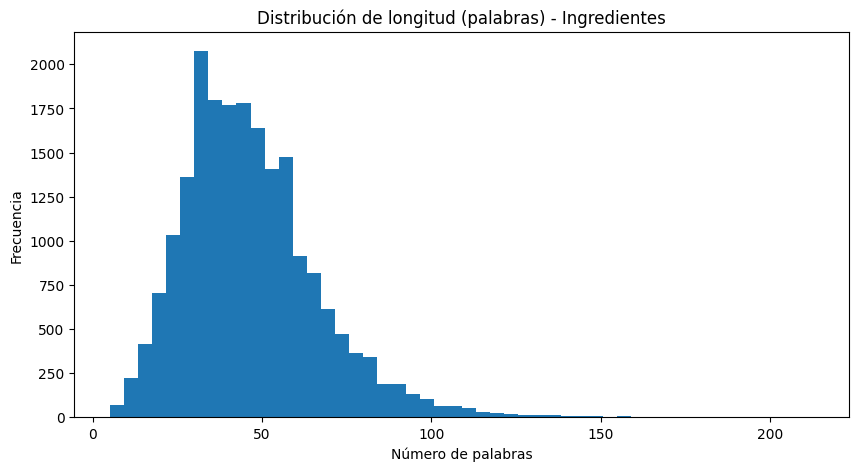

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(df_text["word_len"], bins=50)
plt.title("Distribución de longitud (palabras) - Ingredientes")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

## **4.3 Longitud en tokens**

In [ ]:
# Longitud en tokens (nuevo enfoque)

def count_tokens(text):
    return len(tokenizer(text, truncation=False)["input_ids"])

sample_df = df_text.sample(3000, random_state=42).copy()
sample_df["token_len"] = sample_df["text"].apply(count_tokens)

sample_df["token_len"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

,token_len
count,3000.000000
mean,94.420000
std,34.420544
min,27.000000
50%,90.000000
75%,114.000000
90%,138.000000
95%,157.000000
99%,192.020000
max,328.000000


## **4.4 Histograma tokens**

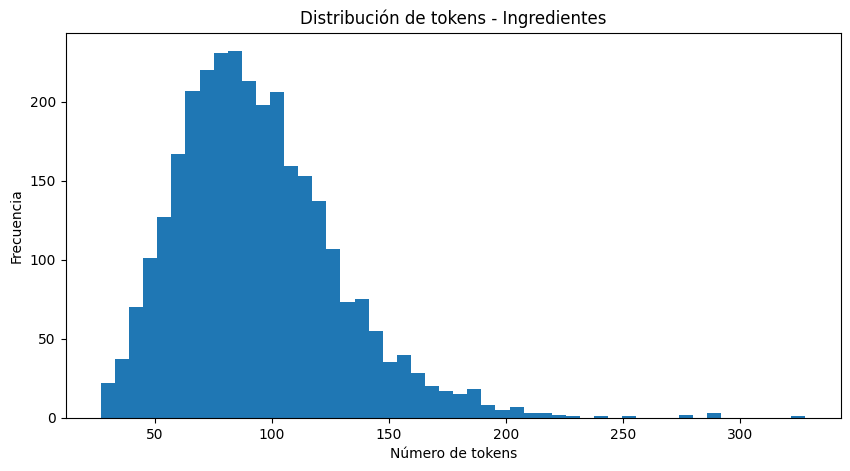

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(sample_df["token_len"], bins=50)
plt.title("Distribución de tokens - Ingredientes")
plt.xlabel("Número de tokens")
plt.ylabel("Frecuencia")
plt.show()

**Análisis de longitud del texto y selección de `max_length`**

A partir del análisis de la longitud de los textos construidos (Categoría + Ingredientes), se observa que:

- la mayoría de los ejemplos se concentran entre 50 y 140 tokens,
- el percentil 75 se encuentra aproximadamente entre 110 y 120 tokens,
- el percentil 90 alrededor de 140–160 tokens,
- y el percentil 95 cercano a 180–200 tokens.

Dado este comportamiento, se selecciona un valor de:

**`max_length = 160`**

Esta decisión permite:

- capturar aproximadamente el 90% de los ejemplos sin truncamiento significativo,
- reducir el consumo de memoria,
- aumentar la eficiencia del entrenamiento,
- y mejorar la estabilidad del modelo en el entorno de Google Colab.

Aunque algunos ejemplos más largos pueden ser truncados, estos corresponden a casos menos frecuentes, por lo que el impacto en el aprendizaje global es limitado.

Esta decisión representa una optimización clave, permitiendo aprovechar mejor el dataset disponible y mejorar el rendimiento del modelo.

# **5. Preprocesamiento y Tokenización**

Una vez construido el texto unificado basado en `Categoria` e `Ingredientes`, se procede a la tokenización del corpus para su uso en el modelo GPT-2.

**Tokenización**

Dado que los modelos GPT-2 trabajan con secuencias de longitud fija, es necesario definir un parámetro `max_length`, que en este proyecto se estableció en:

**`max_length = 160`**

Este valor permite capturar la mayor parte de los ejemplos sin truncamiento significativo, manteniendo eficiencia computacional.

---

###**Batch size y limitaciones computacionales**

En tareas de deep learning es común utilizar batch sizes grandes (por ejemplo, 64 o 128). Sin embargo, en modelos de lenguaje como GPT-2, el costo computacional es considerablemente mayor debido a:

- el número de parámetros del modelo,
- el procesamiento secuencial de tokens,
- y el almacenamiento de activaciones y gradientes durante el entrenamiento.

Por esta razón, se utilizan valores pequeños:

**`per_device_train_batch_size = 2 o 4`**

Estos valores son adecuados para el entorno de ejecución (GPU T4 en Google Colab) y permiten entrenar el modelo de forma estable.

---

### **Batch size efectivo**

Para compensar el uso de batch sizes pequeños, se emplea la técnica de **gradient accumulation**, que permite simular un batch más grande.

Por ejemplo:

```python
per_device_train_batch_size = 4
gradient_accumulation_steps = 4
```
equivalente a un batch size efectivo de 4 x 4 = 16

Esto significa que el modelo acumula gradientes durante varios pasos antes de actualizar los pesos, logrando un efecto similar al de un batch más grande sin exceder las limitaciones de memoria.

## **5.1 Ajuste de Compatibilidad**

In [ ]:
# Ajuste de compatibilidad entre tokenizer y modelo

# Si el tokenizer no tiene pad_token, usamos eos_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Redimensionar embeddings al tamaño real del tokenizer
model.resize_token_embeddings(len(tokenizer))

# Configuración explícita para entrenamiento
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.use_cache = False

print("tokenizer.vocab_size:", tokenizer.vocab_size)
print("len(tokenizer):", len(tokenizer))
print("pad_token_id:", tokenizer.pad_token_id)
print("eos_token_id:", tokenizer.eos_token_id)
print("embedding size:", model.get_input_embeddings().weight.shape[0])

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


tokenizer.vocab_size: 50265
len(tokenizer): 50266
pad_token_id: 50265
eos_token_id: 50265
embedding size: 50266


La salida obtenida confirma que el ajuste de compatibilidad fue exitoso: el tamaño de la matriz de embeddings del modelo coincide ahora con el tamaño efectivo del tokenizer (`len(tokenizer)`), garantizando que todos los tokens utilizados durante la tokenización tengan una representación válida dentro del modelo.

## **5.2 Tokenización**

In [ ]:
# Tokenización

max_length = 160

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

tokenized_dataset = formatted_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=formatted_dataset["train"].column_names
)

tokenized_dataset


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 20236
    })
})

## **5.3 Verificación de Compatibilidad**

In [ ]:
# Verificación de rangos de tokens


sample_ids = tokenized_dataset["train"]["input_ids"][:1000]

max_id = max(max(x) for x in sample_ids)
min_id = min(min(x) for x in sample_ids)

print("Min token id:", min_id)
print("Max token id:", max_id)
print("Embedding size:", model.get_input_embeddings().weight.shape[0])

assert max_id < model.get_input_embeddings().weight.shape[0], "Hay tokens fuera del rango de embeddings"
print("Verificación correcta: todos los tokens están dentro del rango válido.")

Min token id: 6
Max token id: 50265
Embedding size: 50266
Verificación correcta: todos los tokens están dentro del rango válido.


In [ ]:
# Limpieza de columnas

tokenized_dataset = tokenized_dataset.remove_columns(
    [col for col in tokenized_dataset["train"].column_names if col != "input_ids" and col != "attention_mask"]
)

## **5.4 Train / Validation Split**

In [ ]:
# Train / Validation split

split_dataset = tokenized_dataset["train"].train_test_split(
    test_size=0.1,
    seed=42
)

train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 18212
})
Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 2024
})


# **6. Generación con el modelo base**


Antes de realizar el fine-tuning, es importante evaluar cómo se comporta el modelo base frente a la nueva tarea planteada: generar ingredientes a partir de una categoría culinaria.

Esta evaluación cumple dos objetivos:

1. establecer una línea base cualitativa,
2. verificar si el modelo posee conocimiento previo suficiente sobre asociaciones entre tipos de recetas e ingredientes.

Se realizarán dos tipos de prueba:

- **prompts estructurados**, siguiendo el formato exacto del dataset de entrenamiento,
- **prompts naturales**, con formulaciones más abiertas y cercanas al lenguaje cotidiano.

Esto permitirá analizar no solo la calidad del modelo base, sino también su sensibilidad al formato del prompt.

## **6.1 Función de generación**

Se define una función de generación basada en `model.generate()`, la cual permite controlar distintos aspectos del muestreo, tales como:

- `max_new_tokens`: número máximo de tokens generados,
- `temperature`: nivel de aleatoriedad / creatividad,
- `top_k`: selección entre los tokens más probables,
- `top_p`: muestreo acumulado por probabilidad.

Además, se utiliza `no_repeat_ngram_size=3` para reducir repeticiones excesivas en la salida generada.

In [ ]:
# Función de generación

def generate_text(prompt, model, tokenizer, max_new_tokens=120, temperature=0.8, top_k=50, top_p=0.95):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)

## **6.2 Prompts de prueba**

En esta primera evaluación se utilizan prompts con la misma estructura que tendrá el corpus de entrenamiento:

```text
### Categoría:
postres

### Ingredientes:

In [ ]:
# Prompts estructurados de prueba


prompts_structured = [
    "### Categoría:\npostres\n\n### Ingredientes:\n",
    "### Categoría:\nvegetarianos\n\n### Ingredientes:\n",
    "### Categoría:\nsopas\n\n### Ingredientes:\n",
    "### Categoría:\npollo\n\n### Ingredientes:\n"
]

for i, p in enumerate(prompts_structured, 1):
    print("=" * 100)
    print(f"PROMPT ESTRUCTURADO {i}")
    print(generate_text(
        p,
        model,
        tokenizer,
        max_new_tokens=100,
        temperature=0.7,
        top_k=50,
        top_p=0.95
    ))
    print()

PROMPT ESTRUCTURADO 1
### Categoría:
postres

### Ingredientes:
=0,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,37,39,40,41,42,43,44,45,4548,3-PlásticoPlácidoPlácioPláico

PROMPT ESTRUCTURADO 2
### Categoría:
vegetarianos

### Ingredientes:
vete, ici, icio, ui, io, ío, ír, íes, uir, ís, irías, irá, iré, ill, ien, ía, uerón, uis, iste, ue, uil, ino, uo, ono, uen, ü, ué, uido, iu, ii, uit, ū, uele, a

PROMPT ESTRUCTURADO 3
### Categoría:
sopas

### Ingredientes:
stica: 167## Inajeción: 167-## Concentración: 167 -## Propio: 167,## Sintético: 167.## Improvisación: 167 ## Invención: 167 --## Reto: 167--## Sustitución: 170 --#- ¡Qué idiota!- ¿Qué pasa?- ¡Ese tipo me está volviendo loco!- ¡Mira!¡Un tipo me estaba persiguiendo!¿Qué hacemos?¡Le

PROMPT ESTRUCTURADO 4
### Categoría:
pollo

### Ingredientes:
##_ Ingrediente:Denominación: xiquinta letra.La letra M es el número del expediente.Si la letra X es el nombre del expediente, la letra Y es el ape


***Se evidencian limitaciones importantes en su capacidad para generar contenido relevante dentro del dominio culinario:***

---

**Falta de adaptación al formato**

El modelo no logra interpretar correctamente la estructura semiestructurada propuesta. Esto se refleja en:

- generación de símbolos y caracteres irrelevantes,
- secuencias numéricas sin sentido,
- plantillas vacías o incompletas,
- y ausencia de listas coherentes de ingredientes.

Este comportamiento sugiere que el modelo base no ha sido expuesto durante su preentrenamiento a este tipo de formatos, por lo que no logra continuar la estructura de manera adecuada.

---

**Desviación fuera del dominio culinario**

En varios casos, el modelo genera contenido completamente ajeno al contexto de recetas, incluyendo:

- texto técnico o normativo,
- fragmentos con lenguaje legal o administrativo,
- estructuras propias de documentos formales.

Esto indica que el modelo está activando conocimiento general del lenguaje aprendido durante su preentrenamiento, pero no posee especialización en el dominio culinario.

---

**Ausencia de coherencia semántica**

No se observa correspondencia entre la categoría proporcionada y el contenido generado. Por ejemplo:

- para la categoría "postres" no aparecen ingredientes típicos como azúcar, harina o leche,
- para "sopas" se generan textos legales,
- y para "vegetarianos" se producen listas sin significado claro.

Esto evidencia que el modelo no está estableciendo relaciones semánticas entre la categoría y los ingredientes.

---

**Interpretación general**

En conjunto, estos resultados indican que el modelo base:

- no comprende el formato estructurado propuesto,
- no está alineado con la tarea de generación de ingredientes,
- y no logra capturar asociaciones entre categorías culinarias e ingredientes.

---

**Conclusión de la sección**

El desempeño del modelo base frente a prompts estructurados es claramente deficiente, lo cual es esperable dado que este tipo de formato no forma parte de su entrenamiento original.

Estos resultados establecen una línea base importante para el proyecto, evidenciando la necesidad de aplicar fine-tuning sobre un corpus específico que permita al modelo aprender tanto:

- la estructura del formato,
- como el dominio culinario.

Este análisis servirá como punto de comparación para evaluar posteriormente el impacto del modelo ajustado.

# **6.3 Prueba con Prompts mas naturales**

In [ ]:
# Prompts naturales de prueba

prompts_naturales = [
    "Ingredientes típicos para un postre:\n",
    "Qué ingredientes lleva una receta vegetariana:\n",
    "Ingredientes comunes para una sopa:\n",
    "Qué ingredientes se usan para cocinar pollo:\n"
]

for i, p in enumerate(prompts_naturales, 1):
    print("=" * 100)
    print(f"PROMPT NATURAL {i}")
    print(generate_text(
        p,
        model,
        tokenizer,
        max_new_tokens=100,
        temperature=0.8,
        top_k=50,
        top_p=0.95
    ))
    print()

PROMPT NATURAL 1
Ingredientes típicos para un postre:
ALAS, el pan de maíz y el pan con calabaza, y las tortillas o patatas con la mezcla del pan.La masa se envuelve en una capa de pan que va a hornear a la plancha.Al momento de hornear, la masa se enfría hasta que se derrite, y el horno se abre.Una vez horneada, la torta de calabaza es rellenada con queso y crema de huevo.A continuación, la bandeja se sirve de forma tradicional en una cacer

PROMPT NATURAL 2
Qué ingredientes lleva una receta vegetariana:
...La sopa de cebolla es un plato tradicional de Oaxaca, México.Es un caldo de pasta preparado con cebolla, ajo, carne y queso, la cual se suele acompañar con queso cheddar, queso y huevo duro.El plato es originario de Puebla y es típico de las regiones de la Mixteca, Isthmilia, Oaxaca y Veracruz.Se sirve fría y caliente, con papas o ensalada.El queso es típico del estado de Puebla.El arroz con leche es otro plato típico del

PROMPT NATURAL 3
Ingredientes comunes para una sopa:
.Papas

***Observaciones sobre prompts naturales (modelo base)***

Al evaluar el modelo base utilizando prompts más naturales, se observa un comportamiento diferente respecto a los prompts estructurados.

En este caso, los prompts utilizados fueron del tipo:

- "Ingredientes típicos para un postre"
- "Qué ingredientes lleva una receta vegetariana"
- "Ingredientes comunes para una sopa"
- "Qué ingredientes se usan para cocinar pollo"

---

**Mejora en fluidez del lenguaje**

A diferencia de los prompts estructurados, el modelo genera texto más fluido y gramaticalmente coherente. Se observa:

- uso de frases completas,
- continuidad narrativa,
- menor presencia de caracteres extraños o símbolos.

Esto sugiere que el modelo responde mejor a formatos de lenguaje natural, los cuales son más cercanos a su distribución de entrenamiento original.

---

**Presencia parcial de vocabulario culinario**

En algunos casos aparecen ingredientes o elementos relacionados con cocina, tales como:

- azúcar, vainilla, canela (postres),
- tomate, ajo, aceite de oliva (vegetarianos),
- pimienta, leche, huevos (pollo).

Esto indica que el modelo posee cierto conocimiento general del dominio culinario.

---

**Falta de estructura en la salida**

A pesar de la mejora en fluidez, el modelo no genera listas claras de ingredientes. En su lugar:

- mezcla ingredientes con instrucciones,
- introduce pasos de preparación innecesarios,
- no separa elementos de forma ordenada.

Esto limita la utilidad de la salida para la tarea específica de generación de ingredientes.

---

**Inconsistencias semánticas**

Se observan varios problemas de coherencia:

- inclusión de ingredientes incorrectos (ej. huevos en recetas vegetarianas),
- combinaciones poco realistas,
- repetición de ingredientes,
- y mezcla de contextos culinarios.

Además, en algunos casos el modelo deriva hacia texto técnico o económico (precios, regulaciones), lo cual evidencia falta de control temático.

---

**Comparación implícita con prompts estructurados**

En relación con la sección anterior:

- los prompts naturales producen texto más fluido,
- pero los prompts estructurados fallan más fuertemente en formato y coherencia.

Esto sugiere que el modelo base:

- entiende mejor el lenguaje natural,
- pero no está preparado para seguir estructuras específicas ni generar salidas controladas.

---

Interpretación general
**bold text**
El modelo base presenta un desempeño moderadamente mejor con prompts naturales en términos de fluidez, pero sigue mostrando limitaciones importantes:

- no logra generar listas de ingredientes de forma estructurada,
- no mantiene coherencia completa con la categoría,
- y presenta errores semánticos frecuentes.

---

**Conclusión de la sección**

En conjunto, los resultados indican que el modelo base posee conocimiento general del lenguaje y cierto entendimiento del dominio culinario, pero no es capaz de resolver la tarea específica de generación de ingredientes de forma precisa.

Esto refuerza la necesidad de aplicar fine-tuning, con el fin de:

- enseñar al modelo el formato esperado,
- reforzar asociaciones entre categorías e ingredientes,
- y mejorar la coherencia de la generación.

## **7. Fine-tuning del modelo**

Una vez evaluado el modelo base, se procede al fine-tuning sobre el corpus completo construido a partir de las variables `Categoria` e `Ingredientes`.


## **7.1 Data Collator**

In [ ]:
# Data collator para causal language modeling

from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

## **7.2 Training Arguments**

**Justificación de la configuración de entrenamiento**

La configuración de entrenamiento fue ajustada considerando tres factores:

1. **Longitud reducida de las secuencias**  
   Al trabajar únicamente con `Categoria` e `Ingredientes`, las entradas son mucho más cortas, lo que permite aumentar el batch size.

2. **Uso del dataset completo**  
   Resulta viable entrenar con todo el conjunto de datos disponible tras la partición train/validation.

3. **Estabilidad computacional**  
   Se priorizó una configuración estable en Google Colab con GPU T4, evitando precisión mixta (`fp16`) y utilizando gradient accumulation para lograr un batch efectivo mayor sin comprometer la memoria.

In [ ]:
## Argumentos de entrenamiento optimizados


from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./gpt2-ingredientes-categoria",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_steps=50,
    fp16=False,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none"
)

## **7.3 Trainer**

In [ ]:
# Inicialización del Trainer


from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator
)

# **7.4 Entrenamiento**

In [ ]:
# Entrenamiento

trainer.train()

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,1.434001,1.455843
2,1.334768,1.396702
3,1.343272,1.381754


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=6831, training_loss=1.4638845449030757, metrics={'train_runtime': 3067.9484, 'train_samples_per_second': 17.809, 'train_steps_per_second': 2.227, 'total_flos': 4461234831360000.0, 'train_loss': 1.4638845449030757, 'epoch': 3.0})

**Resultados del entrenamiento**

El proceso de fine-tuning se completó de manera estable durante 3 épocas, sin presentar problemas numéricos ni errores de convergencia.

Los resultados obtenidos fueron los siguientes:

| Época | Training Loss | Validation Loss |
|------|---------------|-----------------|
| 1 | 1.4340 | 1.4558 |
| 2 | 1.3348 | 1.3967 |
| 3 | 1.3433 | 1.3818 |

A partir de estos resultados se observan varios aspectos importantes:

- la pérdida de validación disminuye de forma consistente a lo largo de las épocas,
- la pérdida de entrenamiento y validación se mantienen cercanas entre sí,
- y no se evidencian señales fuertes de sobreajuste.

Esto sugiere que el modelo logró aprender asociaciones relevantes entre categorías culinarias e ingredientes, manteniendo una capacidad razonable de generalización sobre ejemplos no vistos.



# **8. Evaluación del modelo después del fine-tuning**

## **8.1 Métricas finales del entrenamiento**

Una vez finalizado el entrenamiento, se evalúa el comportamiento del modelo ajustado desde dos perspectivas:

1. **Cuantitativa**, mediante la revisión de la pérdida de entrenamiento, pérdida de validación y perplejidad.
2. **Cualitativa**, mediante la generación de recetas con los mismos prompts utilizados previamente para el modelo base.

Esta comparación permite analizar si el fine-tuning logró adaptar el modelo al dominio culinario y mejorar su capacidad para generar recetas más coherentes y estructuradas.

In [ ]:
#  Historial de entrenamiento
history = pd.DataFrame(trainer.state.log_history)
history

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,3.185751,1.942450,9.927739e-06,0.043927,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.045868,3.137541,9.780268e-06,0.087854,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.847006,2.732281,9.632798e-06,0.131781,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.749452,1.765630,9.485327e-06,0.175708,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.635014,1.800838,9.337856e-06,0.219635,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,1.328994,1.837598,3.421324e-07,2.898748,6600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,1.349969,1.747252,1.946616e-07,2.942675,6700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,1.343272,1.487068,4.719068e-08,2.986602,6800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,NaN,NaN,NaN,3.000000,6831,1.381754,32.0873,63.078,31.539,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Logs de entrenamiento y validación

train_logs = history[history["loss"].notna()].copy()
eval_logs = history[history["eval_loss"].notna()].copy()

print("Train logs:")
display(train_logs)

print("\nEval logs:")
display(eval_logs)

Train logs:


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,3.185751,1.942450,9.927739e-06,0.043927,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.045868,3.137541,9.780268e-06,0.087854,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.847006,2.732281,9.632798e-06,0.131781,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.749452,1.765630,9.485327e-06,0.175708,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.635014,1.800838,9.337856e-06,0.219635,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,1.360613,1.872037,6.370742e-07,2.810894,6400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,1.375150,1.691507,4.896033e-07,2.854821,6500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,1.328994,1.837598,3.421324e-07,2.898748,6600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,1.349969,1.747252,1.946616e-07,2.942675,6700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Eval logs:


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
22,NaN,NaN,NaN,1.0,2277,1.455843,32.2400,62.779,31.390,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,2.0,4554,1.396702,32.1805,62.895,31.448,NaN,NaN,NaN,NaN,NaN
70,NaN,NaN,NaN,3.0,6831,1.381754,32.0873,63.078,31.539,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Evaluación final

eval_results = trainer.evaluate()
eval_results

{'eval_loss': 1.381753921508789,
 'eval_runtime': 34.6516,
 'eval_samples_per_second': 58.41,
 'eval_steps_per_second': 29.205,
 'epoch': 3.0}

In [ ]:
# Perplejidad

import math

perplexity = math.exp(eval_results["eval_loss"])
print("Eval loss:", eval_results["eval_loss"])
print("Perplexity:", perplexity)

Eval loss: 1.381753921508789
Perplexity: 3.9818794104075206


### Evaluación del modelo ajustado

Tras el proceso de fine-tuning, se obtuvo:

- **Validation Loss:** 1.3817  
- **Perplexity:** 3.98  

---

#### Interpretación de la perplejidad

La perplejidad es una métrica utilizada en modelos de lenguaje para medir qué tan bien el modelo predice la siguiente palabra en una secuencia.

En términos simples, una perplejidad de 3.98 indica que, en promedio, el modelo considera aproximadamente 4 posibles opciones para cada token, lo cual refleja un nivel bajo de incertidumbre.

---

#### Análisis del resultado

Este valor de perplejidad se considera bajo para tareas de generación de texto, lo cual sugiere que:

- el modelo ha aprendido patrones consistentes dentro del dataset,
- existe una buena correspondencia entre las categorías y los ingredientes,
- y la tarea propuesta es adecuada para el modelo utilizado.

---


*Nota: En modelos de lenguaje sobre Loss:*

< 2 → muy bueno

2 – 3 → bueno

5 → malo

*La perplejidad mide qué tan “seguro” está el modelo:*

interpretación:

| Perplexity | Interpretación |
| ---------- | -------------- |
| > 50       | muy mala       |
| 20–50      | mala           |
| 10–20      | regular        |
| 5–10       | buena          |
| **< 5**    | muy buena   |


## **8.2 Generación con el modelo fine-tuned**

Una vez completado el proceso de fine-tuning, se evalúa nuevamente el modelo utilizando los mismos prompts definidos previamente.

El objetivo es comparar el comportamiento del modelo antes y después del entrenamiento, analizando:

- coherencia de los ingredientes generados,
- alineación con la categoría proporcionada,
- estructura de la salida,
- y calidad general del texto.

Al igual que en la evaluación del modelo base, se utilizan dos tipos de prompts:

- prompts estructurados,
- prompts naturales.

Esto permite evaluar no solo la mejora en la tarea específica, sino también la capacidad de generalización del modelo.

In [ ]:
# Prompts estructurados

prompts_structured = [
    "### Categoría:\npostres\n\n### Ingredientes:\n",
    "### Categoría:\nvegetarianos\n\n### Ingredientes:\n",
    "### Categoría:\nsopas\n\n### Ingredientes:\n",
    "### Categoría:\npollo\n\n### Ingredientes:\n"
]

for i, p in enumerate(prompts_structured, 1):
    print("=" * 100)
    print(f"PROMPT ESTRUCTURADO {i} (MODELO AJUSTADO)")
    print(generate_text(
        p,
        model,
        tokenizer,
        max_new_tokens=80,
        temperature=0.7,
        top_k=50,
        top_p=0.9
    ))
    print()

PROMPT ESTRUCTURADO 1 (MODELO AJUSTADO)
### Categoría:
postres

### Ingredientes:
2 tazas de arroz, 1 taza de leche, 1/2 taza de azúcar, 1 litro de leche condensada, 1 cucharadita de polvo de hornear, 1 limón, ½ taza de harina, 1 huevo, ¼ taza de agua, 4 cucharadas de azúcar blanca, 1 pizca de sal, 1 cuchara de leche o de soja, ¾ taza de aceite de coco,

PROMPT ESTRUCTURADO 2 (MODELO AJUSTADO)
### Categoría:
vegetarianos

### Ingredientes:
1 taza de leche entera, 1/2 taza de azúcar, 1 taza de agua, 1½ tazas de leche condensada, 1 litro de agua (2 tazas) de leche evaporada, 2 tazas de azúcar moreno, 1 limón, 1 cucharadita de comino, ½ taza de crema de leche, 1 ½ cucharaditas de orégano, 1 vaso pequeño

PROMPT ESTRUCTURADO 3 (MODELO AJUSTADO)
### Categoría:
sopas

### Ingredientes:
½ taza de azúcar, ¼ taza de agua, ½ taza cucharadita de esencia de vainilla, 1/4 de taza de ron blanco, 1 cucharada de canela, 1½ tazas de agua tibia, 1 ½ tazas cucharaditas de azúcar o chocolate, 1 taza de ha

### 8.2.1 Observaciones sobre prompts estructurados

Tras el fine-tuning, se observa una mejora significativa en el comportamiento del modelo frente a prompts estructurados.

---

#### a. Mejora en la estructura de salida

El modelo ahora es capaz de:

- continuar correctamente el formato del prompt,
- generar listas de ingredientes separadas por comas,
- y producir secuencias coherentes sin símbolos extraños ni ruido.

A diferencia del modelo base, desaparecen completamente los caracteres irrelevantes, estructuras numéricas sin sentido y fragmentos de texto técnico.

---

#### b. Coherencia con la categoría

Se evidencia una mejora importante en la relación entre la categoría y los ingredientes generados:

- Para **"postres"**, aparecen ingredientes típicos como azúcar, leche, harina y huevo.
- Para **"pollo"**, se generan ingredientes plausibles como cebolla, ajo, pimiento y aceite.
- En general, los ingredientes son reconocibles y pertenecen al dominio culinario.

---

#### c. Limitaciones observadas

A pesar de la mejora, aún se presentan algunas inconsistencias:

- En categorías como **"vegetarianos"**, aparecen ingredientes no siempre adecuados (ej. productos lácteos o combinaciones más propias de postres).
- En **"sopas"**, se observa contaminación con ingredientes dulces (vainilla, azúcar), lo cual sugiere mezcla de patrones aprendidos.
- Hay repetición de ciertos ingredientes (azúcar, leche), indicando sesgo del dataset.

---

#### d. Interpretación

Estos resultados indican que el modelo ha aprendido:

- la estructura del formato,
- el estilo de listas de ingredientes,
- y parcialmente la relación semántica entre categorías e ingredientes.

Sin embargo, todavía presenta cierta dificultad para separar completamente los contextos culinarios entre categorías.

---

#### e. Conclusión

El fine-tuning permitió una mejora sustancial en:

- estructura,
- dominio,
- y coherencia general.

No obstante, persisten errores semánticos menores, lo cual es esperable dado el tamaño del modelo y la complejidad del dataset.

## **8.3 Prueba con prompts naturales**

In [ ]:
# Prompts naturales - modelo ajustado


prompts_naturales = [
    "Ingredientes típicos para un postre:\n",
    "Qué ingredientes lleva una receta vegetariana:\n",
    "Ingredientes comunes para una sopa:\n",
    "Qué ingredientes se usan para cocinar pollo:\n"
]

for i, p in enumerate(prompts_naturales, 1):
    print("=" * 100)
    print(f"PROMPT NATURAL {i} (MODELO AJUSTADO)")
    print(generate_text(
        p,
        model,
        tokenizer,
        max_new_tokens=80,
        temperature=0.8,
        top_k=50,
        top_p=0.9
    ))
    print()

PROMPT NATURAL 1 (MODELO AJUSTADO)
Ingredientes típicos para un postre:
[] tarro de crema de leche, para el gusto, sin azúcar ni edulcorante, que pueden ser de limón, perejil o cilantro, o cualquier otro de la misma familia.Para su postre, lo invitamos a disfrutar de las delicias de la cocina china, las cuales son muy variadas, entre las cuales se encuentran: arroz blanco, arroz negro, arroz de maíz,

PROMPT NATURAL 2 (MODELO AJUSTADO)
Qué ingredientes lleva una receta vegetariana:
ADROFRENO DE RADIO o LALIBESTA.Una mezcla de frutos del bosque, nueces, etc.El sabor es muy dulce.Un postre para el gusto.Un pequeño bocado para el paladar.Es un postre que se prepara de manera casera.Es rico en antioxidantes y en vitaminas, antioxidante, fibra y vitaminas.Es muy rico en sodio.Es bueno

PROMPT NATURAL 3 (MODELO AJUSTADO)
Ingredientes comunes para una sopa:
[] de ají molido, cortado en trozos de 3 a 5 cm, sin pepas ni chiles, molido y picado, picado, y cortado en rodajas, sin masticar.Es un i

### 8.3.1 Observaciones sobre prompts naturales (modelo ajustado)

En los prompts naturales, el modelo ajustado muestra mejoras respecto al modelo base, aunque con un comportamiento menos controlado que en los prompts estructurados.

---

#### 1. Mejora en coherencia parcial

En algunos casos se observan ingredientes relevantes, por ejemplo:

- pollo → pimiento, cebolla, zanahoria, tomate
- sopa → ají, ingredientes regionales

Esto indica que el modelo ha internalizado ciertos patrones del dominio culinario.

---

#### 2. Persistencia de ruido y estructura libre

Sin embargo, el modelo:

- mezcla ingredientes con descripciones narrativas,
- introduce texto explicativo innecesario,
- y no genera listas claras como en el formato estructurado.

---

#### 3. Inconsistencias semánticas

Se observan problemas como:

- generación de palabras irrelevantes o inventadas,
- mezcla de contextos (postres con cocina china, por ejemplo),
- repeticiones o estructuras incompletas.

---

#### 4. Sensibilidad al formato

El modelo responde significativamente mejor cuando el prompt sigue el formato del dataset.

Esto confirma que:

El modelo ha aprendido fuertemente el patrón estructurado de entrenamiento.

---

#### Conclusión

El modelo ajustado mejora en prompts naturales en términos de dominio, pero su mejor desempeño se obtiene claramente en prompts estructurados.

Esto resalta la importancia del diseño del prompt en modelos generativos.

# **9. Comparación antes vs después**

**Comparación: modelo base vs modelo ajustado**

La comparación entre el modelo base y el modelo ajustado permite evidenciar claramente el impacto del fine-tuning.

---

**Modelo base**

- incapacidad para seguir el formato estructurado,
- generación de texto fuera de dominio (legal, técnico, incoherente),
- ausencia de listas de ingredientes,
- alta presencia de ruido.

---

**Modelo ajustado**

- generación estructurada de listas de ingredientes,
- alineación general con el dominio culinario,
- desaparición casi total de ruido y texto irrelevante,
- mayor coherencia en la salida.

---

**Diferencias clave observadas**

| Aspecto | Modelo Base | Modelo Ajustado |
|--------|-----------|----------------|
| Formato | No lo respeta | Sí lo respeta |
| Dominio culinario | Muy bajo | Medio Alto |
| Coherencia | Baja | Moderada–alta |
| Ruido | Alto | Bajo |
| Control de salida | Nulo | Bueno |




# **10. Conclusión**

El presente proyecto tuvo como objetivo evaluar la capacidad de un modelo generativo basado en GPT-2 para aprender patrones dentro de un dominio específico, mediante un proceso de fine-tuning sobre un corpus estructurado.

---

**Desempeño del modelo base**

El modelo base evidenció limitaciones importantes al enfrentarse a la tarea propuesta:

- incapacidad para seguir estructuras específicas de entrada,
- generación de texto fuera de dominio,
- baja coherencia semántica,
- y presencia significativa de ruido.

Si bien el modelo mostraba cierta capacidad de generación lingüística, no lograba producir resultados útiles en el contexto de recetas culinarias.

---
**Impacto del fine-tuning**

Tras el proceso de ajuste, el modelo mostró una mejora clara en múltiples dimensiones:

- capacidad para seguir el formato estructurado del dataset,
- generación de contenido dentro del dominio culinario,
- reducción significativa del ruido,
- y mayor coherencia en las secuencias generadas.

Estos resultados evidencian que el fine-tuning permite especializar un modelo generalista en tareas concretas de generación de texto.

---

**Evaluación cuantitativa**

El modelo ajustado alcanzó una perplejidad aproximada de: **3.98**

Este valor indica un bajo nivel de incertidumbre en la predicción de tokens, lo cual sugiere que el modelo ha aprendido patrones consistentes dentro del corpus.

La cercanía entre la pérdida de entrenamiento y validación también evidencia una adecuada capacidad de generalización, sin señales claras de sobreajuste.

---

**Sensibilidad al formato del prompt**

Uno de los hallazgos más relevantes del proyecto es la fuerte dependencia del modelo respecto al formato del prompt:

- el modelo responde mejor a estructuras similares a las vistas durante el entrenamiento,
- mientras que en prompts más naturales la generación es menos controlada.

Esto confirma la importancia del diseño del prompt en modelos generativos y su relación directa con el desempeño.

---

**Limitaciones del modelo**

A pesar de los resultados positivos, se identificaron algunas limitaciones:

- inconsistencias semánticas en ciertas categorías,
- mezcla ocasional de contextos culinarios,
- repetición de ciertos patrones frecuentes en el dataset,
- y menor control en escenarios de generación libre.

Estas limitaciones son consistentes con el tamaño del modelo utilizado y la naturaleza probabilística de la generación de texto.

